# Practical 2: Statistics and time series tests

<div class="alert alert-block alert-success">
<b>Objectives:</b> In this notebook we use Pandas to perform statistical analysis on air quality time series data. We explore the structure of our data before building a machine learning model in Practical 3.

 - 1) <a href="#Part1">Using Pandas to load and merge data</a>
      * <a href="#Exercise1">Exercise 1: Merge air quality and meteorological data</a>
 - 2) <a href="#Part2">Statistical analysis: correlation</a>
      * <a href="#Exercise2">Exercise 2: Network correlation heatmap</a>
      * <a href="#Exercise3">Exercise 3: Diurnal profiles across the network</a>
 - 3) <a href="#Part3">Stationarity: lag plots, ACF/PACF, and ADF test</a>
      * <a href="#Exercise4">Exercise 4: Lag plots for supersite PM2.5 and BC</a>
      * <a href="#Exercise5">Exercise 5: ACF and PACF for NO2</a>
 - 4) <a href="#Part4">Time series decomposition and linear regression</a>
 - 5) <a href="#Part5">Feature engineering for machine learning</a>
 - 6) <a href="#Part6">Why we hold data back: the train/test split</a>
</div>

<div style="border-left: 6px solid #1f77b4; background-color: #f0f8ff; padding: 15px; margin: 15px 0;">

### ✅ <span style="color:#1f77b4">Key Learning Outcomes – Practical 2</span>

By the end of this session you will be able to:

1. **Quantify relationships** between pollution and weather using correlation coefficients and heatmaps
2. **Visualise network data** across multiple monitoring sites and understand real-world data gaps
3. **Assess stationarity** using lag plots, ACF/PACF plots, and the Augmented Dickey-Fuller test
4. **Decompose a time series** into trend, seasonality, and residuals using STL
5. **Explain residual variation** with a simple linear regression on weather variables
6. **Engineer temporal features** (hour, day-of-week, month) that encode the patterns you found
7. **Understand train/test splits** and why time order must be respected for time series models

These skills directly prepare you for Practical 3, where you will build and interpret a machine learning model.
</div>

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">
After each exercise you will also find a box presented like so. If you click on the text, you will be presented with the Python solution. You are free to copy-and-paste this in to your own code box after trying to solve the problem yourself.

<summary><strong>🧪 Click to show solution</strong></summary>

</div>

Statistics and statistical tests play a crucial role in understanding and working with time-series data. Time-series data involves observations taken over a specific period, often at regular intervals, and it presents unique challenges due to the temporal nature of the data points. Statistical analysis allows us to uncover meaningful patterns, trends, and relationships within time-series data, enabling us to make informed decisions and predictions. By applying statistical techniques such as descriptive statistics, regression analysis, and hypothesis testing, we can quantify the characteristics of the time-series, identify significant factors influencing its behavior, and assess the reliability of observed patterns. These tools provide a systematic framework for extracting insights from time-series data, enabling us to better understand and interpret the underlying dynamics, detect anomalies or outliers, and make accurate forecasts. Ultimately, statistical analysis empowers us to harness the power of time-series data and derive actionable insights for various fields, including finance, economics, climate science, and many others.

<div class="alert alert-block alert-info">
<b>JupyterHub users:</b> The next cell detects your environment automatically. On JupyterHub it runs silently and does nothing — no action needed.
</div>

First we need to check what environment we are running this notebook in, so we can install and download/unzip files accordingly

In [22]:
if 'google.colab' in str(get_ipython()):
    
    # Mount the Google Drive at mount
    from google.colab import drive
    mount='/content/gdrive'
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Switch to the directory on the Google Drive that you want to use
    import os
    from os import path
    
    drive_root = mount + "/My Drive/Colab Notebooks/MPEC_bootcamp/Time-series-analytics-course"
    # Change to the directories to get data files
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
        
else:
    print("not working in Google Colab!")

not working in Google Colab!


## Imports and data path

Run this cell before any other code cell. If you restart the kernel, use *Kernel → Restart & Run All*.

In [23]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('data')

## 1). Using Pandas to open a CSV file and understanding a dataframe <a name="Part1"></a>

First let us load our dataset into a Pandas dataframe. If you remember from our last practical, we can use the internal Pandas function

```python
pd.read_csv(name of CSV file)
```

and then preview our dataframe using the 

```python
<<name of dataframe>>.head()
```
function. We do this below by loading in a CSV file that stores information from a given AURN site. 

In [24]:
df = pd.read_csv(DATA_DIR / 'AURN/MAN3.csv')
df.head()

,date,O3,NO,NO2,NOXasNO2,SO2,PM2.5,NV2.5,V2.5,wd,...,temp,AT2.5,AP2.5,site,code,latitude,longitude,PM10,Ox,NOx
0,2017-01-01 00:00:00,32.26382,3.54940,28.96035,34.40269,1.51405,15.1,13.5,1.6,223.0,...,7.8,8.1,1003.0,Manchester Piccadilly,MAN3,53.48152,-2.237881,NaN,61.22417,32.50975
1,2017-01-01 01:00:00,22.55141,5.82822,42.66724,51.60371,1.42536,5.0,2.7,2.3,227.3,...,7.5,7.7,1002.0,Manchester Piccadilly,MAN3,53.48152,-2.237881,NaN,65.21865,48.49546
2,2017-01-01 02:00:00,30.08518,3.12230,30.79077,35.57824,1.00249,4.4,1.9,2.5,246.5,...,7.4,7.6,1001.0,Manchester Piccadilly,MAN3,53.48152,-2.237881,NaN,60.87595,33.91307
3,2017-01-01 03:00:00,26.79227,2.39918,30.33751,34.01620,1.06902,3.2,2.2,1.0,353.0,...,7.2,7.8,1000.0,Manchester Piccadilly,MAN3,53.48152,-2.237881,NaN,57.12978,32.73669
4,2017-01-01 04:00:00,24.49722,1.97167,27.91915,30.94234,1.20273,3.9,3.9,0.0,28.6,...,6.4,7.5,1000.0,Manchester Piccadilly,MAN3,53.48152,-2.237881,NaN,52.41637,29.89082


I can also check the data type of each column by using the 

```python
<<name of dataframe>>.dtypes
```
function. This is useful for a number of reasons that might include whether we need to convert between, for example, <code> string </code> to <code> float </code> to perform some numerical analysis. As we have already seen, we can also check whether we are using a format called <code> datetime </code>. As the name suggests, this format allows us to perform some really neat data manipulation on time series data.  In the code box below, I check the data types of columns stored in our meteorology dataframe using the <code> .dtypes </code> property of our dataframe. I then change the <code> date </code> column to a datetime format and make this the index of our dataframe. 

In [25]:
df['datetime'] = pd.to_datetime(df['date'])
df_indexed = df.set_index('datetime')
df_indexed.dtypes

date          object
O3           float64
NO           float64
NO2          float64
NOXasNO2     float64
SO2          float64
PM2.5        float64
NV2.5        float64
V2.5         float64
wd           float64
ws           float64
temp         float64
AT2.5        float64
AP2.5        float64
site          object
code          object
latitude     float64
longitude    float64
PM10         float64
Ox           float64
NOx          float64
dtype: object

As a quick reminder from Practical 1, we can check the number of rows and columns loaded with `df.shape`:

In [26]:
print('Shape:', df_indexed.shape)
print('Date range:', df_indexed.index.min(), 'to', df_indexed.index.max())

Shape: (47712, 21)
Date range: 2017-01-01 00:00:00 to 2022-12-10 23:00:00


That is quite a large number of observations! Let's jump straight into an exercise.

<div class="alert alert-block alert-success">
<b> Exercise 1: Merge the air quality and meteorological dataset into a new dataframe. <a name="Exercise1"></a> </b> 
    
Load the meteorological dataset used in the previous practical and merge the data dataframes on the common time index. Feel free to use the code from the first practical. 

</div>

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">

<details>
<summary><strong>🧪 Click to show solution</strong></summary>

```python
#load in boundary layer height, temperature at 2m etc from ECMWF re-analysis data
bl_df = pd.read_csv(DATA_DIR / 'Reanalysis/Picc_ECMWF_data_new.csv')
# Convert this date string to datetime format
bl_df['datetime'] = pd.to_datetime(bl_df['time'])
# Set the index
bl_df=bl_df.set_index('datetime')
# Create a new data frame by merging the other two using the time index as the pivot 
combined_df = pd.merge(df_indexed[['NO2', 'NO', 'PM2.5', 'Ox', 'NOx','temp', 'ws', 'wd']],bl_df[['t2m','u10','v10','blh_final','sp','RH']], how='inner', left_index=True, right_index=True)
# Re-record time metrics in the new data frame
combined_df['hour']=combined_df.index.hour
combined_df['day']=combined_df.index.weekday
combined_df['month']=combined_df.index.month
combined_df['day_of_year']=combined_df.index.day_of_year
combined_df.head()
```

</details>

</div>

In [27]:
# ---- INSERT CODE HERE ----#
#load in boundary layer height, temperature at 2m etc from ECMWF re-analysis data
#load in boundary layer height, temperature at 2m etc from ECMWF re-analysis data

# --------------------------#

,NO2,NO,PM2.5,Ox,NOx,temp,ws,wd,t2m,u10,v10,blh_final,sp,RH,hour,day,month,day_of_year
datetime,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,28.96035,3.54940,15.1,61.22417,32.50975,7.8,4.5,223.0,279.50064,2.443758,2.924213,445.04938,101463.320,0.928495,0,6,1,1
2017-01-01 01:00:00,42.66724,5.82822,5.0,65.21865,48.49546,7.5,4.2,227.3,279.22998,2.332650,3.196304,462.18268,101348.160,0.928607,1,6,1,1
2017-01-01 02:00:00,30.79077,3.12230,4.4,60.87595,33.91307,7.4,2.7,246.5,278.56464,2.213651,3.480007,457.56848,101247.140,0.939088,2,6,1,1
2017-01-01 03:00:00,30.33751,2.39918,3.2,57.12978,32.73669,7.2,3.1,353.0,278.51688,1.790367,3.617465,411.56964,101152.540,0.932534,3,6,1,1
2017-01-01 04:00:00,27.91915,1.97167,3.9,52.41637,29.89082,6.4,3.9,28.6,278.46472,1.589300,3.760885,401.37550,101014.664,0.934428,4,6,1,1


## 2). Statistical analysis on dataframes <a name="Part2"></a>

We have gone to all this trouble to build dataframes. We have practiced selecting a subset and also merging to create a new frame. We can also now perform common statistical operations on our data to try and understand any interesting relationships across multiple variables. 

### 2.1) Correlation coefficients

Correlation coefficients, typically ranging from -1 to +1, provide a numerical measure of the association between variables. A positive correlation coefficient indicates a positive relationship, meaning that as one variable increases, the other tends to increase as well. Conversely, a negative correlation coefficient signifies an inverse relationship, where one variable tends to decrease as the other increases. By quantifying these relationships, correlation coefficients help us understand the degree to which variables are related and how their values move in tandem.

Pandas has a variety of functions for generating stats from our data. In the following code I demonstrate how we can select a subset of our columns and look at the correlation coefficient between each variable. Let us work with our new combined dataframe 'combined_df'.

The first step is to create a correlation coefficient matrix. We can do that by telling Pandas which columns we are interested in:

```python
dataframe[['column 1','column 2','column 3'...etc]]
```

and then using the 

```python
.corr()
```

to this subset. We can remind ourselves of the columns associated with our dataframe:

In [28]:
combined_df.columns

Index(['NO2', 'NO', 'PM2.5', 'Ox', 'NOx', 'temp', 'ws', 'wd', 't2m', 'u10',
       'v10', 'blh_final', 'sp', 'RH', 'hour', 'day', 'month', 'day_of_year'],
      dtype='object')

Then we can derive our relevant coefficients using the following example. Please note we specify the type of coefficient through the variable <code> method </code> which can take one of either <code> pearson </code>,<code> kendall </code> or <code> spearman </code>. You can find more information on which is the most appropriate in the course notes.

The covariance can be normalised by the product of the standard deviation of each variable to give the Pearson Correlation Coefficient; sometimes referred to as Pearsons’ R. A high correlation between two random variables indicates that the two are associated, but that their relationship is not necessarily causal. One criteria of using Pearson coefficient is that the data you are analyzing should be normally distributed. There are ways to check this is the case, and one of the easiest can be through a histogram of the distribution of data. Do you remember how to do this? In the following code we jump straight into generating a correlation coefficient matrix.

In [29]:
corr = combined_df[['temp','ws','RH','u10','v10','blh_final','NO2','PM2.5']].corr(method='pearson')
print("Correlation coefficient matrix = ", corr)

Correlation coefficient matrix =                 temp        ws        RH       u10       v10  blh_final  \
temp       1.000000  0.179523 -0.481948 -0.003686  0.185130   0.322455   
ws         0.179523  1.000000 -0.139063  0.317128  0.460764   0.529102   
RH        -0.481948 -0.139063  1.000000  0.032084  0.108375  -0.580028   
u10       -0.003686  0.317128  0.032084  1.000000  0.328566   0.337802   
v10        0.185130  0.460764  0.108375  0.328566  1.000000   0.147016   
blh_final  0.322455  0.529102 -0.580028  0.337802  0.147016   1.000000   
NO2       -0.379419 -0.287699  0.222669 -0.139536 -0.034218  -0.297877   
PM2.5     -0.114714 -0.235072  0.017098 -0.293125 -0.120657  -0.224065   

                NO2     PM2.5  
temp      -0.379419 -0.114714  
ws        -0.287699 -0.235072  
RH         0.222669  0.017098  
u10       -0.139536 -0.293125  
v10       -0.034218 -0.120657  
blh_final -0.297877 -0.224065  
NO2        1.000000  0.417121  
PM2.5      0.417121  1.000000  


So here we have our correlation coefficients! It would be much easier to visualise this somehow. A popular plotting module used with Pandas is [Seaborn](https://seaborn.pydata.org) which we have already used to produce jointplots and box-plots.

Check out the code snippet below:

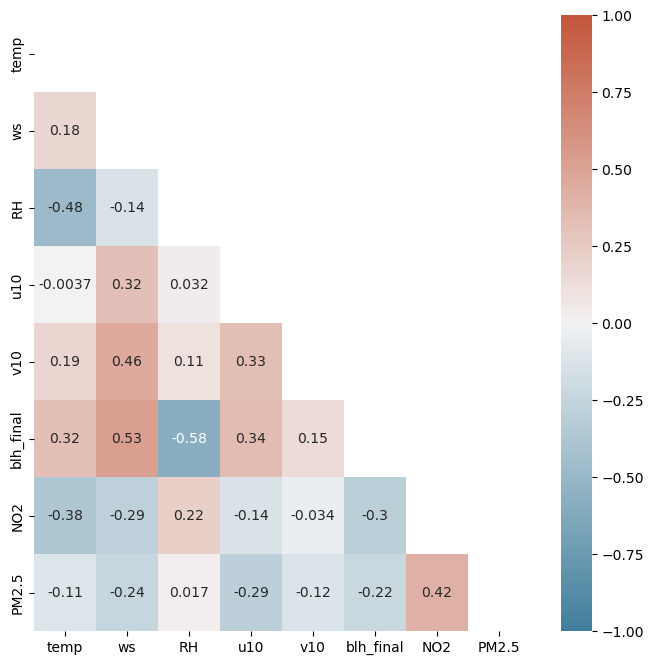

In [30]:
# calculate the correlation matrix
corr = combined_df[['temp','ws','RH','u10','v10','blh_final','NO2','PM2.5']].corr(method='pearson')
# Now use an internal function within Seaborn called '.heatmap'
# Set up the matplotlib plot configuration
fig, ax = plt.subplots(figsize=(8, 8))
# Generate a mask for upper triangle - we want to block this out
mask = np.triu(np.ones_like(corr, dtype=bool))
# Configure a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap
sns.heatmap(corr, annot=True, mask = mask, vmin=-1, vmax=1,cmap=cmap,xticklabels=corr.columns, yticklabels=corr.columns)
# And we now need to show the plot.
plt.show()

We can switch the correlation coefficient method quite easily. In the following code snippet we repeat the above but use the spearman coefficient. 

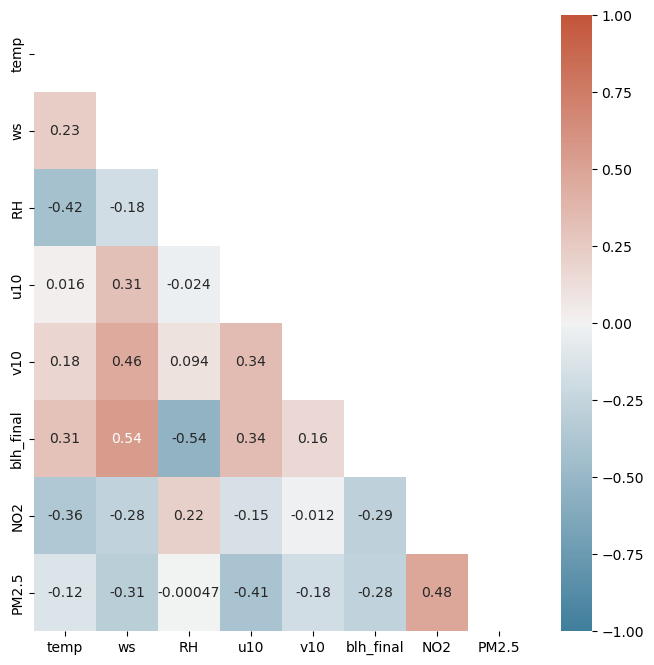

In [31]:
# calculate the correlation matrix
corr = combined_df[['temp','ws','RH','u10','v10','blh_final','NO2','PM2.5']].corr(method='spearman')
# Now use an internal function within Seaborn called '.heatmap'
# Set up the matplotlib plot configuration
fig, ax = plt.subplots(figsize=(8, 8))
# Generate a mask for upper triangle - we want to block this out
mask = np.triu(np.ones_like(corr, dtype=bool))
# Configure a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap
sns.heatmap(corr, annot=True, mask = mask, vmin=-1, vmax=1,cmap=cmap,xticklabels=corr.columns, yticklabels=corr.columns)
# And we now need to show the plot.
plt.show()

We can select some interesting observations here. Take the coeffcient between $NO_{2}$ and wind speed ($ws$) and boundary layer height $blh_final$. 

### 2.2) Comparison across a distributed network <a name="Part2b"></a>

Up to this point we have looked at data from the Piccadilly AURN site. We also have access to a managed low-cost sensor network across Greater Manchester and our own air quality supersite (Firs), which includes a reference-grade FIDAS PM instrument and a black carbon aethalometer.

The cell below loads all sources and merges them into a single hourly DataFrame (`new_df`). Note how we use a **right merge** to retain the full supersite time series, accepting gaps where individual sensors have missing data — a common reality in network deployments.

In [32]:
# ── Supersite: reference-grade FIDAS PM instrument ──────────────────────────
ss_df = pd.read_csv(DATA_DIR / 'Supersite/FIRS_FIDAS_2022.csv',
                    index_col='datetime', parse_dates=True, dayfirst=True)
ss_df.loc[ss_df['SS_PM2.5'] > 200, 'SS_PM2.5'] = np.nan
ss_df = ss_df.resample('60s').mean()
ss_df['date_stamp'] = ss_df.index.values

# ── Supersite: Black Carbon aethalometer ─────────────────────────────────────
bc_df = pd.read_csv(DATA_DIR / 'Supersite/FIRS_BC_2022.csv',
                    index_col='datetime', parse_dates=True, dayfirst=True)
bc_df = bc_df.resample('60s').mean()
bc_df['date_stamp'] = bc_df.index.values

# ── Low-cost network sensors ─────────────────────────────────────────────────
def _load_modpm(filename):
    df = pd.read_csv(DATA_DIR / f'Supersite/{filename}',
                     index_col='timestamp', parse_dates=True)
    df.index = pd.to_datetime(df.index.strftime('%d/%m/%y %H:%M:%S'),
                              format='%d/%m/%y %H:%M:%S')
    df['date_stamp'] = df.index.values
    return df

sensor_435_df = _load_modpm('MOD-PM-435.csv')
sensor_427_df = _load_modpm('MOD-PM-427.csv')
sensor_430_df = _load_modpm('MOD-PM-430.csv')

# ── Supersite co-location sensor ─────────────────────────────────────────────
sensor_461_df = pd.read_csv(DATA_DIR / 'Supersite/MOD-PM-00461-SS.csv',
                            index_col='timestamp_local', parse_dates=True)
sensor_461_df.index = pd.to_datetime(
    sensor_461_df.index.strftime('%d/%m/%y %H:%M:%S'), format='%d/%m/%y %H:%M:%S')
sensor_461_df = sensor_461_df[['461_SS_pm25', '461_SS_pm10']].resample('60s').mean()
sensor_461_df['date_stamp'] = sensor_461_df.index.values

# ── Sequential right-merge → resample to hourly ──────────────────────────────
new_df = pd.merge(sensor_435_df[['435_PM2.5', '435_PM10', 'date_stamp']], ss_df, how='right')
new_df = pd.merge(sensor_427_df[['427_PM2.5', '427_PM10', 'date_stamp']], new_df, how='right')
new_df = pd.merge(sensor_430_df[['430_PM2.5', '430_PM10', 'date_stamp']], new_df, how='right')
new_df = pd.merge(sensor_461_df[['461_SS_pm25', '461_SS_pm10', 'date_stamp']], new_df, how='right')
new_df = pd.merge(bc_df, new_df, how='right')
new_df = new_df.set_index('date_stamp').resample('1h').mean()
new_df['time'] = new_df.index.values

print(f'Network dataset: {new_df.shape[0]:,} hourly observations, {new_df.shape[1]} variables')
new_df.head()

/var/folders/1j/63hgx37j03dgffxw1tmpn29w0000gp/T/ipykernel_46360/2986552446.py:16: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(DATA_DIR / f'Supersite/{filename}',
/var/folders/1j/63hgx37j03dgffxw1tmpn29w0000gp/T/ipykernel_46360/2986552446.py:16: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(DATA_DIR / f'Supersite/{filename}',
/var/folders/1j/63hgx37j03dgffxw1tmpn29w0000gp/T/ipykernel_46360/2986552446.py:16: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(DATA_DIR / f'Supersite/{filename}',


Network dataset: 9,504 hourly observations, 29 variables


,BC_Conc,UVPM_370_nm,BC_470 (ug/m3),BC_520 (ug/m3),BC_590 (ug/m3),BC_660 (ug/m3),BC_950 (ug/m3),qc_flag_BC,qc_flag_UVPM,qc_flag_BC_470,...,427_PM10,435_PM2.5,435_PM10,Cn (P/cm3),SS_PM1,SS_PM2.5,SS_PM10,SS_PM_Total,PM_Flag,time
date_stamp,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.567949,0.859525,0.740305,0.665559,0.636305,0.598898,0.569373,1.0,1.0,1.0,...,NaN,NaN,NaN,268.473585,10.293220,13.481356,17.228814,18.630508,1.0,2022-01-01 00:00:00
2022-01-01 01:00:00,0.384400,0.516367,0.469417,0.430333,0.419283,0.399800,0.385950,1.0,1.0,1.0,...,NaN,NaN,NaN,135.439275,5.721667,7.948333,10.180000,10.983333,1.0,2022-01-01 01:00:00
2022-01-01 02:00:00,0.350567,0.460583,0.426867,0.391917,0.382083,0.361900,0.351233,1.0,1.0,1.0,...,NaN,NaN,NaN,115.992537,4.415000,6.061667,7.825000,8.461667,1.0,2022-01-01 02:00:00
2022-01-01 03:00:00,0.345750,0.445483,0.414417,0.381633,0.372533,0.355200,0.346400,1.0,1.0,1.0,...,NaN,NaN,NaN,116.515345,4.148333,5.501667,7.430000,8.190000,1.0,2022-01-01 03:00:00
2022-01-01 04:00:00,0.386817,0.506483,0.466450,0.429083,0.419617,0.398417,0.387200,1.0,1.0,1.0,...,NaN,NaN,NaN,145.994422,5.208333,7.226667,10.286667,12.113333,1.0,2022-01-01 04:00:00


The plot below shows the PM2.5 time series from all sources. Gaps are visible where sensors were offline — this is normal in real-world networks.

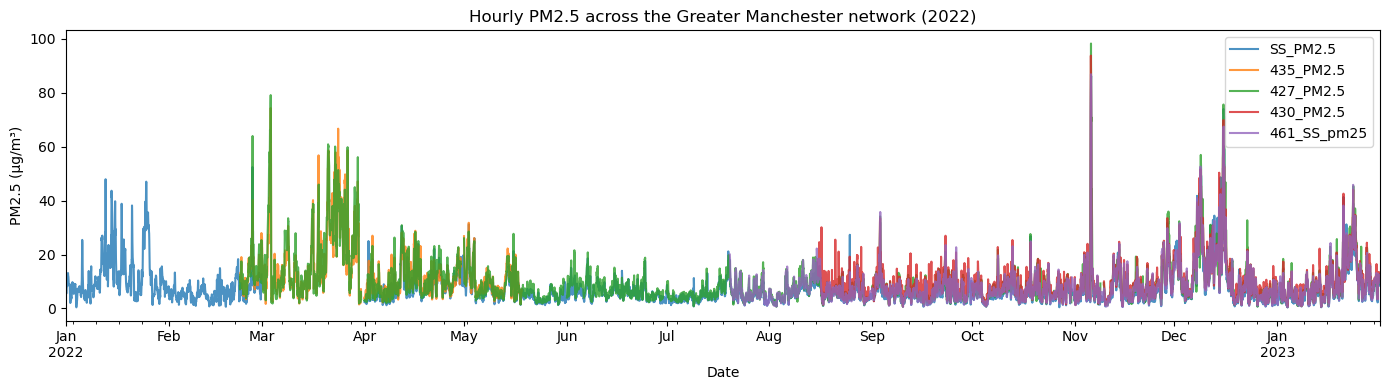

In [33]:
ax = new_df[['SS_PM2.5','435_PM2.5','427_PM2.5','430_PM2.5','461_SS_pm25']].plot(
    figsize=(14, 4), alpha=0.8)
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_xlabel('Date')
ax.set_title('Hourly PM2.5 across the Greater Manchester network (2022)')
plt.tight_layout()
plt.show()

Note that we have a number of periods where data is missing. This can be quite typical in real-world conditions!
Now that we have a wider collection of data on pollutant concentrations, we can once again merge this new dataset with meteorological data. We are going to assume that the reanalysis products we have used up to this point remain a useful representation across our network. Given this is a network from within the city region, this should be a good enough option. 

In fact, we will turn this requirement into the second exercise. 

<div class="alert alert-block alert-success">
<b> Exercise 2: Merge network air quality and meteorological data to create a correlation coefficient matrix of all pollutant and met variables, and plot using a heatmap. <a name="Exercise2"></a> </b> 

Load the meteorological dataset used in the previous practical and merge with the existing <code> new_df </code> dataframe on a common time index. Feel free to use the code from the first practical. Then:
 - Set the index of the new dataframe to a datetime format
 - Create new time metrics including month and time of day
 - Create a correlation coefficient matrix of all pollutant and met variables, and plot using a heatmap. The list of variables to build a correlation coefficient heatmap from the new dataframe would be:
    
<code> ['SS_PM2.5','435_PM2.5','427_PM2.5','430_PM2.5','461_SS_pm25','BC_Conc','RH','blh_final','t2m','u10','v10']</code>
       
</div>

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">

<details>
<summary><strong>🧪 Click to show solution</strong></summary>

```python
#load in boundary layer height, temperature at 2m etc from ECMWF re-analysis data
bl_df = pd.read_csv(DATA_DIR / 'Reanalysis/Picc_ECMWF_data_new.csv')
# Convert this date string to datetime format
bl_df['datetime'] = pd.to_datetime(bl_df['time'])
# Set the index
bl_df=bl_df.set_index('datetime')
# Create the same column that exists in the new_df dataframe to merge on
bl_df['time']=bl_df.index.values

#Now merge the two dataframes
new_df=pd.merge(bl_df,new_df,how='right')
#set the index of the new dataframe to be 'date_stamp'
new_df=new_df.set_index('time')

# Add extra time variable 
new_df['hour']=new_df.index.hour
new_df['day']=new_df.index.weekday
new_df['month']=new_df.index.month

# calculate the correlation matrix
corr = new_df[['SS_PM2.5','435_PM2.5','427_PM2.5','430_PM2.5','461_SS_pm25','BC_Conc','RH','blh_final','t2m','u10','v10']].corr(method='pearson')
```

</details>

</div>

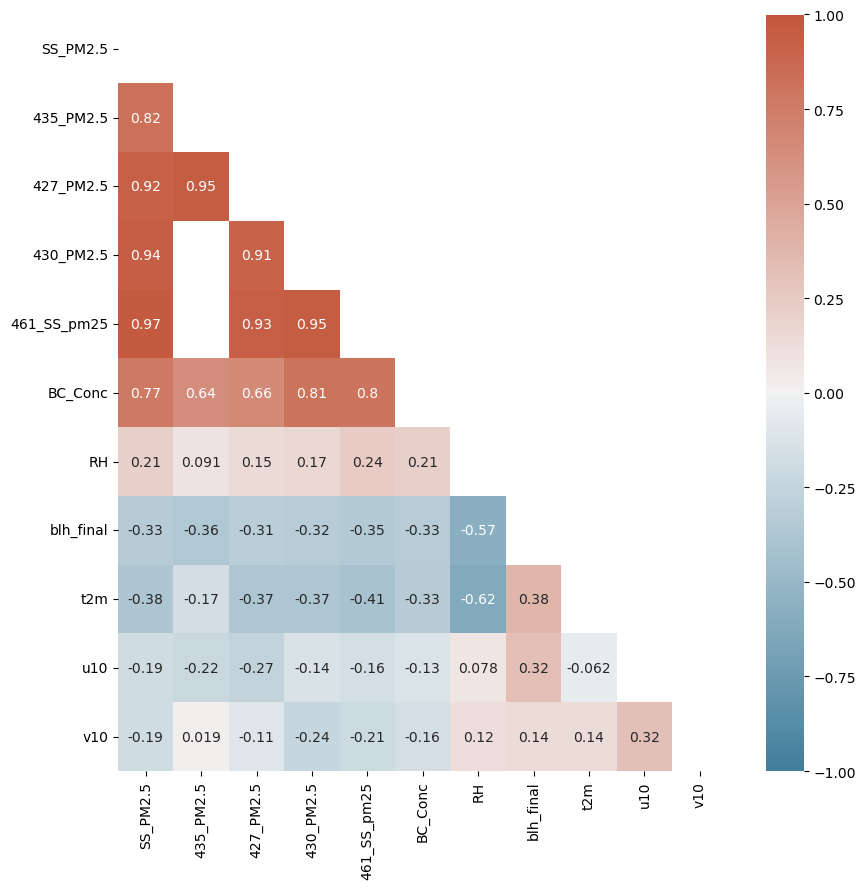

In [34]:
# ---- INSERT CODE HERE ----#

# --------------------------#

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(9, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask=mask, vmin=-1, vmax=1, cmap=cmap,
            xticklabels=corr.columns, yticklabels=corr.columns)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b> Exercise 3: Using the dataframe created in Exercise 2, generate diurnal and monthly profiles for selected pollutants. <a name="Exercise3"></a> </b> 
    
Using the dataframe created in part 'a', we now want to generate diurnal and monthly profiles for the following pollutant variables:
  
<code> ['SS_PM2.5','438_SS_pm25','BC_Conc']</code>
  
which represent the measured PM2.5 at the air quality Firs supersite, in the manchester network and black carbon measured at the supersite respectively. Note that our data is rather limited in that we only have one year. Our dataframe has gaps. We need to make sure we create diurnal profiles across periods where there is data for each variable we are interested in. Here we provide you with another neat trick of pandas dataframes - <code> .dropna() </code>. This allows us to create a new dataframe, with only the pollutant variables we are interested in and for observations that occur in the same time period. Following this:
    
 - Create a figure with 3 subplots where the x variable is hour of day, and the y variable the pollutant of interest.    
       
</div>

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">

<details>
<summary><strong>🧪 Click to show solution</strong></summary>

```python
# Extract new dataframe where there are no NaN entries.
subset_df=new_df[['SS_PM2.5','435_PM2.5','427_PM2.5','461_SS_pm25','RH','BC_Conc','blh_final','t2m','u10','v10']]
# Create a set of diurnal boxplots for 'BC_Conc', 'SS_PM2.5'and '438_SS_pm25'
fig, axes = plt.subplots(1,3,figsize=(12,8))
sns.boxplot(data=subset_df,x=subset_df.index.hour, y=subset_df['SS_PM2.5'], ax=axes[0], showfliers=False).set(xlabel='Hour of day',ylabel='Concentration (μg/m³)')
sns.boxplot(data=subset_df,x=subset_df.index.hour, y=subset_df['435_PM2.5'], ax=axes[1], showfliers=False).set(xlabel='Hour of day',ylabel='Concentration (μg/m³)')
sns.boxplot(data=subset_df,x=subset_df.index.hour, y=subset_df['BC_Conc'], ax=axes[2], showfliers=False).set(xlabel='Hour of day',ylabel='Concentration (μg/m³)')
axes[0].set_title('SS_PM2.5')
axes[1].set_title('435_PM2.5')
axes[2].set_title('BC_Conc')
```

</details>

</div>

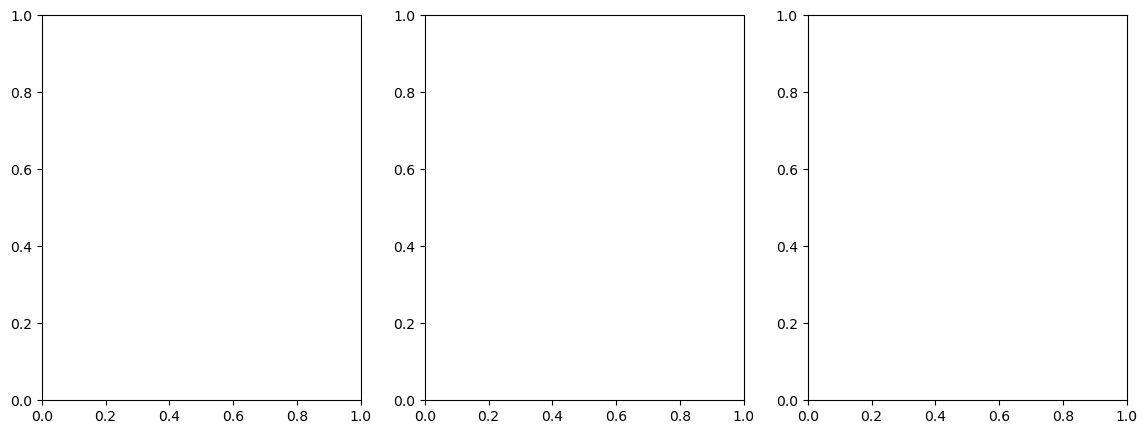

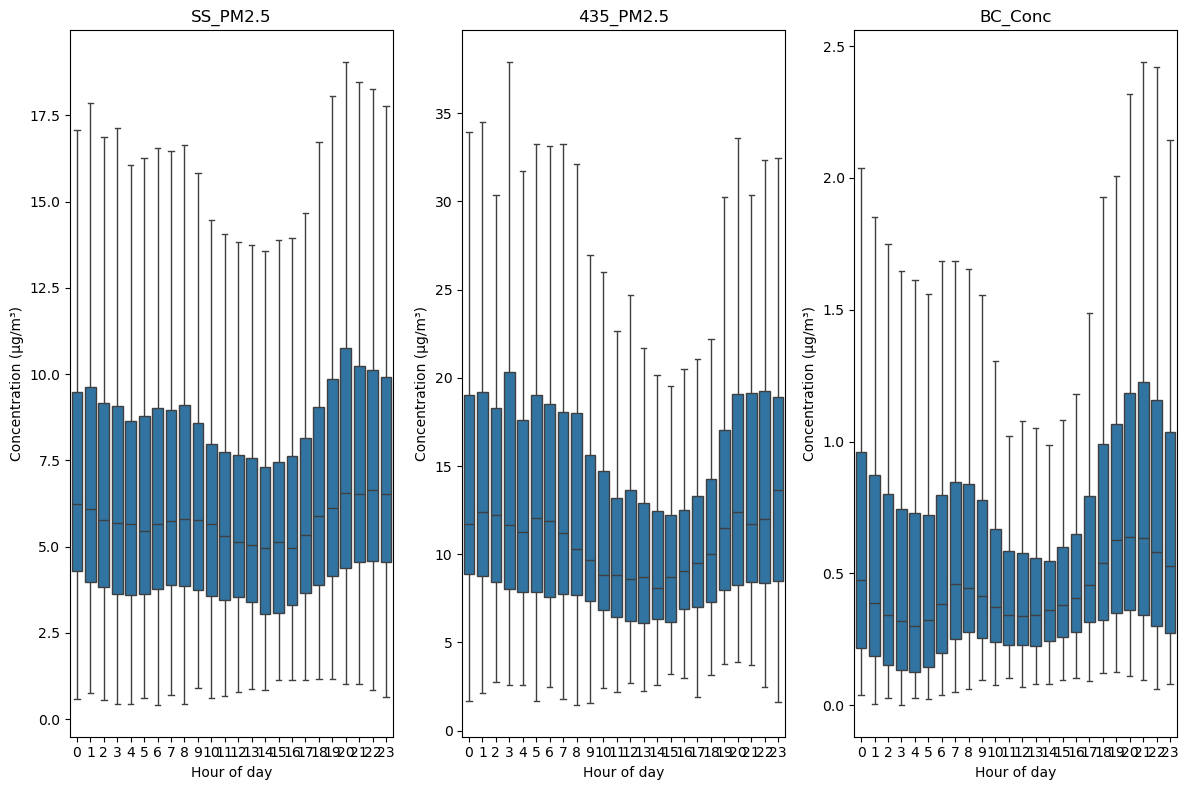

In [35]:
subset_df = new_df[['SS_PM2.5', '435_PM2.5', '427_PM2.5', '461_SS_pm25',
                     'RH', 'BC_Conc', 'blh_final', 't2m', 'u10', 'v10']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# ---- INSERT CODE HERE ----#

# --------------------------#
plt.tight_layout()
plt.show()

What if we wanted to have a single boxplot where  we specify the colour (<code> hue </code> in the previous notebook) according to the different sites? We can use another combined property of Pandas dataframes and Seaborn called <code> melt </code>. In the following code block we create a 'melt' version of our dataframe which effectively stacks the data on top of each other. 

In [36]:
#melt data frame into long format
df_melted = pd.melt(subset_df[['SS_PM2.5','435_PM2.5','427_PM2.5','461_SS_pm25']])

#view first 10 rows of melted data frame
df_melted.head(10)

,variable,value
0,SS_PM2.5,13.481356
1,SS_PM2.5,7.948333
2,SS_PM2.5,6.061667
3,SS_PM2.5,5.501667
4,SS_PM2.5,7.226667
5,SS_PM2.5,8.258333
6,SS_PM2.5,8.226667
7,SS_PM2.5,8.515000
8,SS_PM2.5,8.561667
9,SS_PM2.5,8.876667


Now we can create a new boxplot and specify the hue by <code> variable </code>. In the proceeding plot, you will find that one measurement site is distinctly higher than the other.

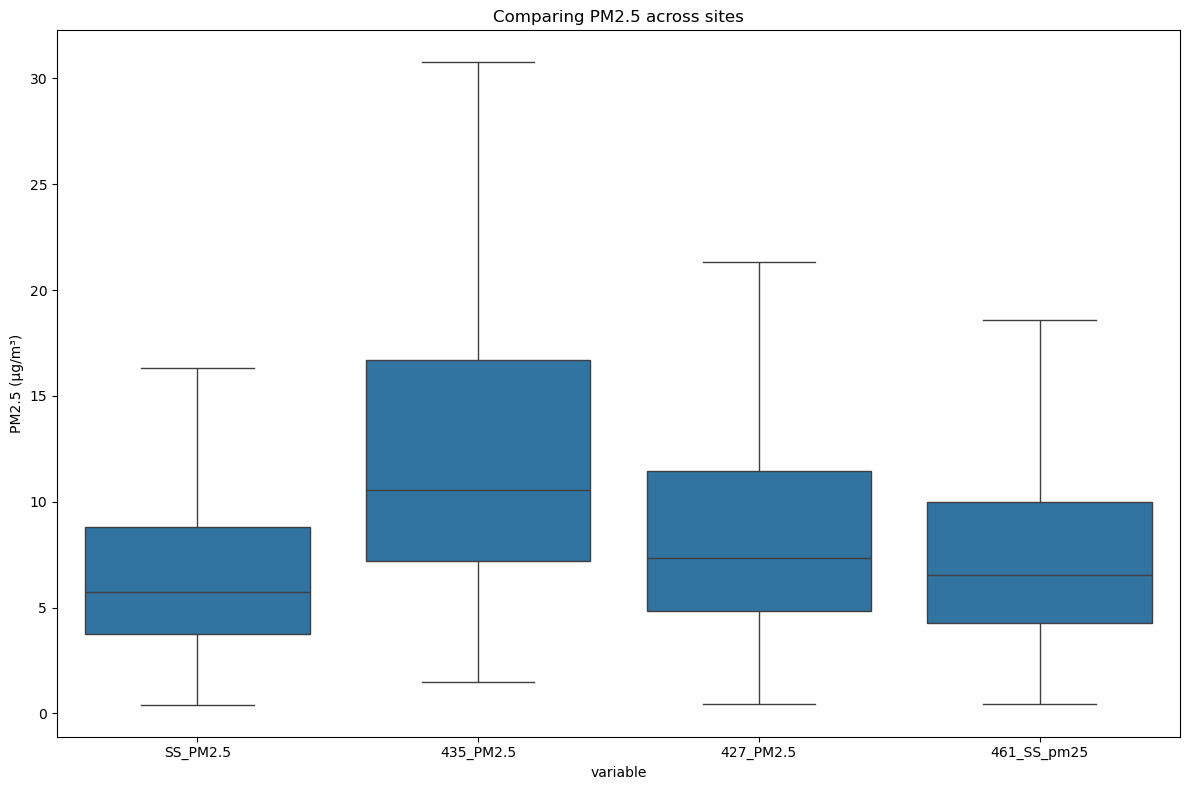

In [37]:
#create seaborn boxplots by group
fig, axes = plt.subplots(figsize=(12, 8))
sns.boxplot(x='variable', y='value', showfliers=False, data=df_melted, ax=axes)
axes.set_title('Comparing PM2.5 across sites')
axes.set_ylabel('PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

# 3) Stationarity: lag plots, ACF/PACF, and the ADF test <a name="Part3"></a>

For time series data we also talk about whether the series is **stationary** or **non-stationary**. Before we define each in turn, take a look at time series displayed in Figure (3.1) below

<img src="images/stationary_examples.png" alt="Nine examples of time series data" style="width: 800px;"/>

*Figure 3.1 Nine examples of time series data; (a) Google stock price for 200 consecutive days; (b) Daily change in the Google stock price for 200 consecutive days; (c) Annual number of strikes in the US; (d) Monthly sales of new one-family houses sold in the US; (e) Annual price of a dozen eggs in the US (constant dollars); (f) Monthly total of pigs slaughtered in Victoria, Australia; (g) Annual total of lynx trapped in the McKenzie River district of north-west Canada; (h) Monthly Australian beer production; (i) Monthly Australian electricity production. [Original source](https://towardsdatascience.com/detecting-stationarity-in-time-series-data-d29e0a21e638)*

These univariate series may resemble any number of pollution time series. However they are fundamentally very different. We can see this by eye, but we can also start to characterise them in a numerically descriptive way. 
The original authors of the paper from which this figure is taken give several heuristics used to rule out stationarity in the above plots, corresponding to the basic characteristic of stationary processes (which we discuss shortly):

  - Prominent seasonality can be observed in series (d), (h) and (i).
  - Noticeable trends and changing levels can be seen in series (a), (c), (e), (f) and (i).
  - Series (i) shows increasing variance.

The authors also add that although the strong cycles in series (g) might appear to make it non-stationary, the timing of these cycles makes them unpredictable (due to the underlying dynamic dominating lynx population, driven partially by available feed). This leaves series (b) and (g) as the [only stationary series](https://towardsdatascience.com/detecting-stationarity-in-time-series-data-d29e0a21e638).


But what do we mean by stationary and seasonality? We define these below. The reason we would like to quantify these properties is because we may wish to understand what an appropriate model of our data might be. This could be used to time-series forecasting, but also to quantify *expected changes in signal from inferred or known processes*. Most forecasting methods assume that a distribution has stationarity. An absence of stationarity can cause unexpected or bizarre behaviors.

## 3.1) Stationarity

We first define a **stationary** process as follows. You may find some definitions a little contradictory, but we will summarise the key things we are looking for at the end of this section:

<blockquote> A stationary process has the property that the mean, variance and autocorrelation structure do not change over time. Stationarity can be defined in precise mathematical terms, but for our purpose we mean a flat looking series, without trend, constant variance over time, a constant autocorrelation structure over time and no periodic fluctuations (seasonality).</blockquote>

Clearly Figure (3.1) shows that the data does change; however the way it changes will not change with time if it is stationary. Going back to our previous figure, we said that *series (b) and (g) are the only stationary series*. The summary statistics will stay fairly constant. Notice already we are using terms such as *fairly*. We dont define these strictly. If the way it changes does not change with time, then we might expect a fairly simple
function describes the time evolution. If it does, then great!  

This leads us nicely to **non-stationary** time series. Take a look at the bottom plot in Figure (3.1). Unlike the previous figure, there is clearly a change in underlying trend with time. For a non-stationary time series we make the following distinction:

<blockquote>Entries in a non-stationary time series show seasonal effects. We observe that trends and a range of structures vary with time. Following the first point, the mean and variance vary with time. These features cause difficulties for models built around assumed stationary statistics. </blockquote>

How do we test for stationarity? Pandas comes with a handy ’lag plot’ to start to add another visual to aid detection of stationary versus non-stationary. The following graphs show an example of using this function for PM2.5 and wind speed values over 1 month at hourly intervals taken from our existing dataset. Lag plots are used to check if a data set or time series is random. Random data should not exhibit any structure in the lag plot. Non-random structure implies that the underlying data are not random, and may be a non-stationary series.

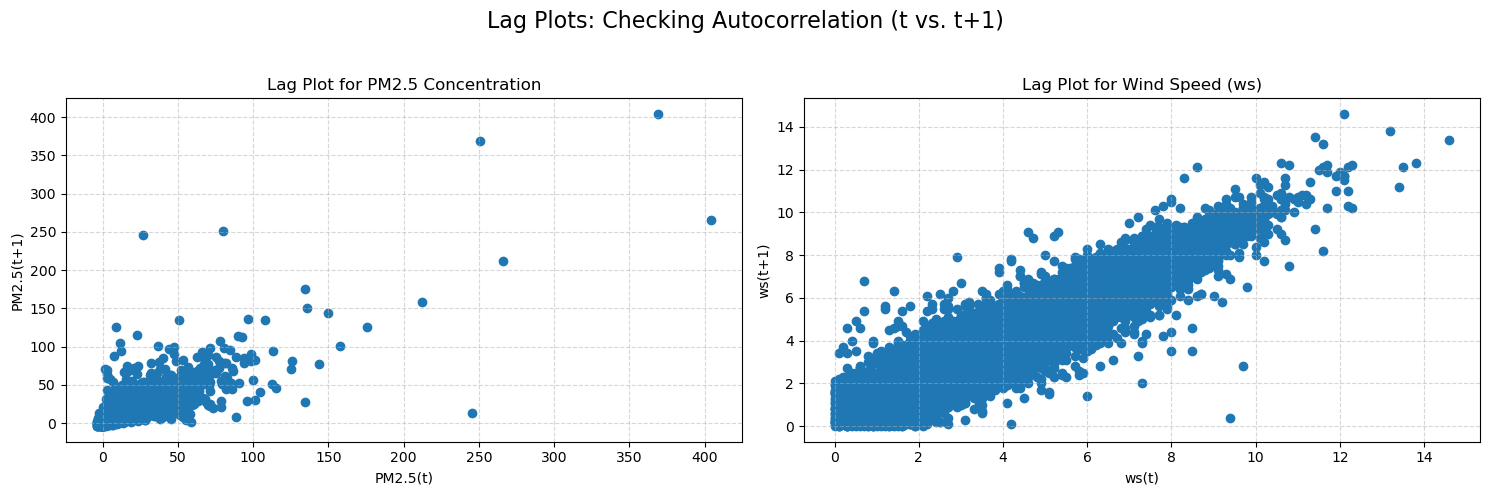

In [38]:
from pandas.plotting import lag_plot

# Create side-by-side lag plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot for PM2.5
lag_plot(combined_df['PM2.5'], ax=ax1)
ax1.set_title('Lag Plot for PM2.5 Concentration')
ax1.set_xlabel('PM2.5(t)')
ax1.set_ylabel('PM2.5(t+1)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot for wind speed
lag_plot(combined_df['ws'], ax=ax2)
ax2.set_title('Lag Plot for Wind Speed (ws)')
ax2.set_xlabel('ws(t)')
ax2.set_ylabel('ws(t+1)')
ax2.grid(True, linestyle='--', alpha=0.5)

# Add a suptitle *before* calling tight_layout with rect
fig.suptitle('Lag Plots: Checking Autocorrelation (t vs. t+1)', fontsize=16)

# Adjust layout so the title doesn’t overlap the plots
fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave top 5% for title

plt.show()

These graphs show there is clearly some structure to our data as currently provided on an hourly basis. This means it is likely that information on previous hourly values could be useful in determining or forecasting the next hour. We get back to this in the third notebook.  What would a daily lag plot look like? Try to complete this in the exercise below. You can use the dataframe already created earlier, namely <code> subset_df </code>. Also focus on the columns 'SS_PM2.5' and 'BC_Conc' to generate the lag plots. 

<div class="alert alert-block alert-success">
<b> Exercise 4: Generate lag plots the supersite PM2.5 and black carbon <a name="Exercise4"></a> </b> 
    
Modify the code below to produce lag plots for hourly and daily averages for the columns <code> SS_PM2.5 </code> and <code> BC_Conc </code>.

</div>

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">

<details>
<summary><strong>🧪 Click to show solution</strong></summary>

```python
# SS_PM2.5 hourly lag plot
lag_plot(subset_df['SS_PM2.5'], ax=axes[0, 0])
axes[0, 0].set_title('SS_PM2.5 - Hourly')
axes[0, 0].set_xlabel('SS_PM2.5(t)')
axes[0, 0].set_ylabel('SS_PM2.5(t+1)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# SS_PM2.5 daily lag plot
lag_plot(daily_df['SS_PM2.5'], ax=axes[0, 1])
axes[0, 1].set_title('SS_PM2.5 - Daily Avg')
axes[0, 1].set_xlabel('SS_PM2.5(t)')
axes[0, 1].set_ylabel('SS_PM2.5(t+1)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# BC_Conc hourly lag plot
lag_plot(subset_df['BC_Conc'], ax=axes[1, 0])
axes[1, 0].set_title('BC_Conc - Hourly')
axes[1, 0].set_xlabel('BC_Conc(t)')
axes[1, 0].set_ylabel('BC_Conc(t+1)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# BC_Conc daily lag plot
lag_plot(daily_df['BC_Conc'], ax=axes[1, 1])
axes[1, 1].set_title('BC_Conc - Daily Avg')
axes[1, 1].set_xlabel('BC_Conc(t)')
axes[1, 1].set_ylabel('BC_Conc(t+1)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
```

</details>

</div>

In [ ]:
# Compute daily average values from hourly data
daily_df = subset_df[['SS_PM2.5', 'BC_Conc']].resample('D').mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# ---- INSERT CODE HERE ----#
# Hint: use lag_plot(series, ax=axes[row, col]) for hourly and daily series

# --------------------------#
plt.tight_layout()
plt.show()


#### Understanding the Lag Plots: Insights into Atmospheric PM2.5 and Black Carbon

Lag plots are a diagnostic tool used to **visually assess autocorrelation** — how a variable relates to its own past values over time. For atmospheric pollutants like **PM2.5** and **black carbon (BC)**, this is essential to understanding their behavior and sources.

##### What These Lag Plots Reveal:

1. **Autocorrelation and Persistence**  
   - If points in the lag plot form a **clear line or curve**, it indicates **temporal persistence** — high values tend to follow high values, and vice versa.
   - This suggests pollutant build-up under stable atmospheric conditions, like low wind or temperature inversions.

2. **Randomness vs Structure**  
   - A **random scatter** implies the data is more independent — perhaps due to fast-changing meteorological conditions.
   - A **patterned distribution** points to consistent emission sources or persistent atmospheric conditions.

3. **Hourly vs Daily Behavior**  
   - **Hourly lag plots** may reveal **diurnal cycles**, like traffic peaks or night-time atmospheric layering.
   - **Daily lag plots** highlight **longer-term trends**, such as regional transport or pollution episodes.

4. **Comparing PM2.5 and Black Carbon**  
   - Comparing their lag structures helps distinguish source behavior.
   - Black carbon, often linked to combustion (e.g., traffic, biomass burning), may show stronger autocorrelation due to steady local sources.
   - PM2.5 may vary more, reflecting a combination of primary and secondary sources.

##### Why This Matters

Understanding these temporal relationships helps:
- Identify pollution buildup and decay
- Guide effective sampling strategies
- Inform air quality modeling and forecasting
- Support targeted mitigation policies


There are various levels of stationarity, as you might expect. These can be important when we start to deploy some statistical tests that are used to define whether a series is stationary or not - but they are not always ideal for the data we might have access to. In our air quality data, we often see clearly seasonality in that we patterns emerging over the hours of day and months of the year.   

## 3.2) Seasonality

Many time series display seasonality. By seasonality, we mean periodic fluctuations. For example, retail sales tend to peak for the Christmas season and then decline after the holidays. So time series of retail sales will typically show increasing sales from September through December and declining sales in January and February. We might expect air quality time series to display seasonality. For example, Ozone is higher in the summer months and NO2 should have a singal on a daily scale related to traffic whilst also have a year signal related atmospheric conditions. 

There are multiple ways to check this. These include:

 - Boxplots of diurnal or longer profiles
 - Autocorrrelation plots
 
In exercise 2 you produce a boxplot of diurnal profiles. Can you see a daily signature emerging from these plots? For the second set of tools we take time to describe them and apply them in the following text.


We make continual reference to a time series that is driven by relationships that change with time and those that do not. One way to profile our data in this regards is to explore the strength of relationships between our current observations and those that occurred previously. We use the term lag to refer to $n$ lags prior to the current point in time (e.g. 3 lags could mean 3 hours). Not only does this give us insight into levels of stationarity, but also helps us understand what an appropriate forecasting model might have to consider. For example, should we use the previous 1 or 12 hours? You may then ask, well, if we can access a measure of correlation across different points in time, can we also use this to identify stationary and non-stationary series? It appears the answer is not so clear BUT they are very useful components to identify seasonality. First let us discuss two metrics known as the **Auto-correlation function(ACF)** and **Partial auto-correlation function (PACF)**.

Autocorrelation analysis helps in detecting hidden patterns and seasonality and in checking for randomness. It is especially important when you intend to use a particular model for forecasting because the autocorrelation analysis helps to identify the parameters and suitability of the model. There is slightly more information provided in the course notes; some methods require us to decide how many lagged values we use to predict the next and whether we need to account for a change in trend or not. 

### 3.2.1) Auto-correlation function(ACF) 

The Auto-correlation function (ACF) is the correlation between a time series signal and a lagged version of itself. Recall earlier in section xx we used a definition of stationarity that stated the time series should have constant \textbf{auto correlation} features. That is, data can vary as a function of time but the way in which it varies will not change. The ACF gives us an idea of the persistence, or memory, of that process. Does the influence connect only the previous 3 lags or the past 48? We will look at some examples shortly. Imagine we have measured the concentration of pollutant at time $t=0$ and we start to look at the correlation between the current data and steps before, using intervals of one hour, thus $t_{t-1}$. This can be a useful way of detecting repeated patterns that might otherwise be difficult to detect within the noise of the observation. For our purposes, it can be used to detect non-randomness in a signal and, using that information, build an appropriate time series model.

### 3.2.2) Partial auto-correlation function (PACF)

Partial auto-correlation (PACF) is a little harder to understand, but provides us with very similar insights into our time series data. We still retain information on the correlation between a signal and its lagged version; however this metric attempts to remove the influence of intermediate values. Thus, we remove the effect of the values 12 hours ago on the values from 112 hours ago and so on. The value for the first lag will be the same as the auto-correlation function, but for all other lags it will be different. 

When you do compare a plot for ACF and PACF, you might find, for example, a value at lag 12 remains strong but a value at 24 which was relatively strong in the ACF now becomes weaker in the PACF plot. 

In the following code blocks, we provide example code to generate both ACF and PACF plots in Python for one time-series dataset. In the proceeding example, we ask you to generate the same again but for the range of other time-series found in our dataset.

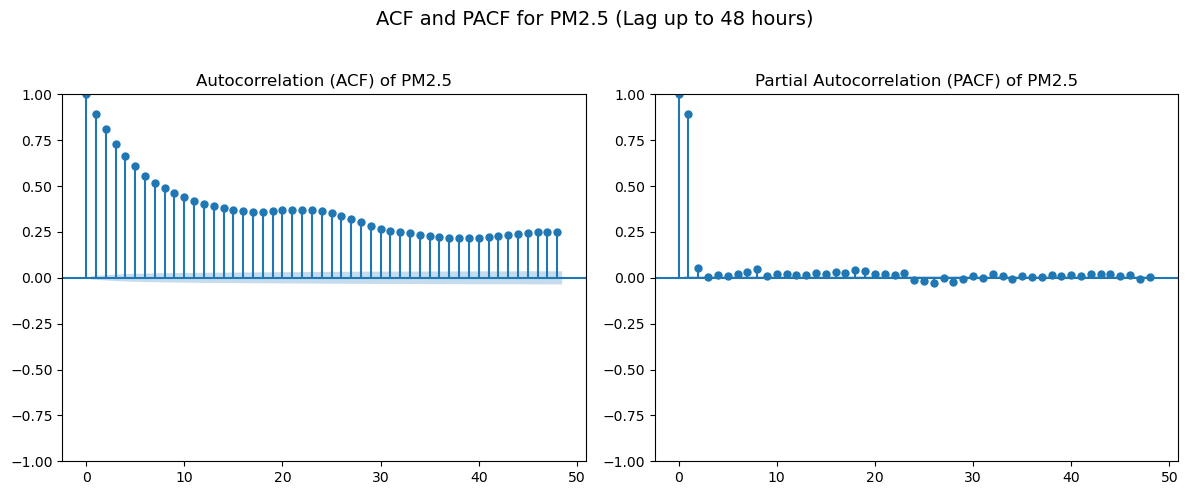

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Optional: drop missing values to avoid errors
pm25_series = combined_df['PM2.5'].dropna()

# Set up side-by-side ACF and PACF plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot ACF and PACF
plot_acf(pm25_series, lags=48, ax=ax[0])
ax[0].set_title('Autocorrelation (ACF) of PM2.5')

plot_pacf(pm25_series, lags=48, ax=ax[1], method='ywm')  # 'ywm' is more stable than default
ax[1].set_title('Partial Autocorrelation (PACF) of PM2.5')

# Add common labels and formatting
fig.suptitle('ACF and PACF for PM2.5 (Lag up to 48 hours)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for title

plt.show()

<div class="alert alert-block alert-success">
<b> Exercise 5: Auto-correlation function (ACF) and Partial auto correlation function (PACF) <a name="Exercise5"></a> </b> 
    
Repeat the above code but for measurements of NO2 from Piccadilly. You will find that there are strong and relatively slowly decaying ACF plots, with significant PACF plots a day before current observations.

<div style="border-left: 6px solid #ff8c00; background-color: #fff3e0; padding: 15px; margin: 15px 0;">

<details>
<summary><strong>🧪 Click to show solution</strong></summary>

```python
# Optional: drop missing values to avoid errors
NO2_series = combined_df['NO2'].dropna()

# Set up side-by-side ACF and PACF plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot ACF and PACF
plot_acf(NO2_series, lags=48, ax=ax[0])
ax[0].set_title('Autocorrelation (ACF) of NO2')

plot_pacf(NO2_series, lags=48, ax=ax[1], method='ywm')  # 'ywm' is more stable than default
ax[1].set_title('Partial Autocorrelation (PACF) of NO2')

# Add common labels and formatting
fig.suptitle('ACF and PACF for NO2 (Lag up to 48 hours)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for title

plt.show()
```

</details>

</div>

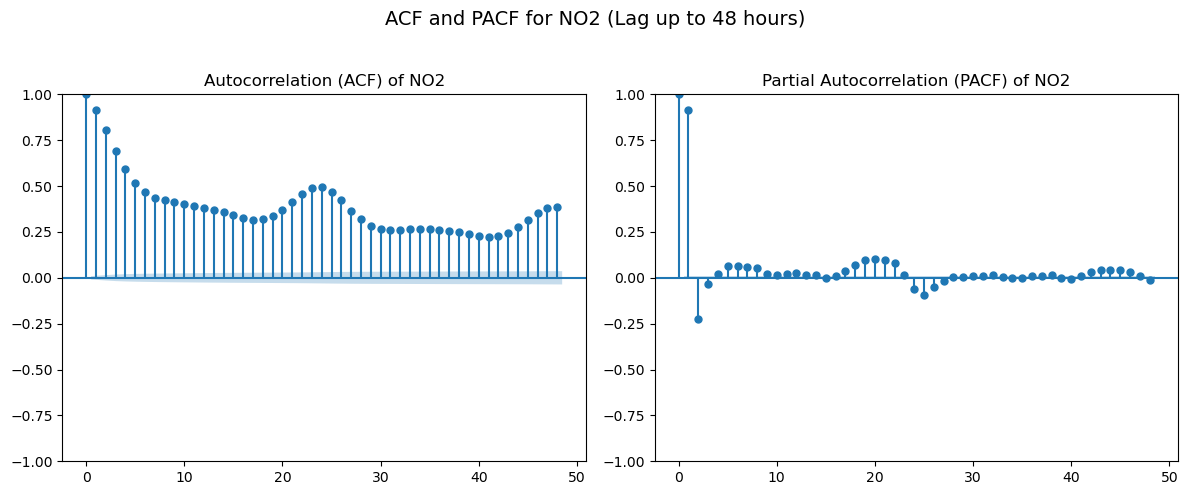

In [21]:
# ---- INSERT CODE HERE ----#

# --------------------------#

### 3.3) The Augmented Dickey-Fuller test <a name="Part3c"></a>

Lag plots and ACF/PACF are visual tools. The **Augmented Dickey-Fuller (ADF) test** gives us a formal statistical answer to "is this time series stationary?"

- **Null hypothesis (H₀):** the series has a unit root — it is *non-stationary*
- **p-value < 0.05:** reject H₀ → series is *stationary*
- **p-value ≥ 0.05:** fail to reject H₀ → series is *non-stationary* (trend or drift present)

For ML, non-stationarity matters because a model trained on one period may not generalise to another if the mean or variance is drifting over time.

In [40]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"  Critical ({k}): {v:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"  Verdict   : {verdict}\n")

adf_test(combined_df["PM2.5"].dropna(), "PM2.5 (hourly)")
adf_test(combined_df["NO2"].dropna(),   "NO2 (hourly)")
adf_test(combined_df["PM2.5"].resample("D").mean().dropna(), "PM2.5 (daily mean)")

ADF Test — PM2.5 (hourly)
  Statistic : -18.0890
  p-value   : 0.0000
  Critical (1%): -3.4305
  Critical (5%): -2.8616
  Critical (10%): -2.5668
  Verdict   : STATIONARY

ADF Test — NO2 (hourly)
  Statistic : -15.5319
  p-value   : 0.0000
  Critical (1%): -3.4305
  Critical (5%): -2.8616
  Critical (10%): -2.5668
  Verdict   : STATIONARY

ADF Test — PM2.5 (daily mean)
  Statistic : -21.9270
  p-value   : 0.0000
  Critical (1%): -3.4336
  Critical (5%): -2.8630
  Critical (10%): -2.5675
  Verdict   : STATIONARY



#### Interpreting the ADF result

A **low p-value (< 0.05)** means we reject the null hypothesis of a unit root — the series is **stationary**. For air quality data this is the expected result, and it is worth understanding exactly what it means (and what it does *not* mean).

**Stationary does not mean "no patterns".** It means the statistical properties of the series — its mean and variance — do not systematically drift over time. The ACF plots you ran earlier showed strong peaks at lags 24 h and 168 h (one week). Those are real, repeating cycles. The ADF test is not contradicting that: it is telling you those cycles are *consistent and bounded*, not drifting further away with each passing year.

Compare this with a stock price, which has a unit root: each day's value builds unpredictably on the last, so the series can wander arbitrarily far from its starting value. Pollution concentrations do not behave that way — rush-hour NO2 peaks every weekday morning, winter PM2.5 is higher than summer, and these patterns repeat year after year within a stable range.

<div class="alert alert-block alert-info">
<b>Why this matters for machine learning:</b> A stationary series means the patterns a model learns from 2017-2019 training data should still hold in 2020 test data, because the underlying statistical structure has not fundamentally shifted. If the series had a unit root, past patterns would be an unreliable guide to the future and any model performance metrics would be misleading.
</div>

If we go back to the concept of stationarity; we can use auto and partial correlation functions described in to understand our data a little more. 

Recall we can use auto-correlation as a measure of dependencies between our current observation and observations at certain intervals prior to this point in time. For a completely random time series, the ACF plot would show near 0 values for all lags prior to our current observation. Caution must be applied to interpreting the value of the ACF coefficient but you can make relative comparisons. Imagine we studied a process whereby we knew that there was a strong relationship between our measured variable with that measured at lag 'k'. We could expect the ACF coefficient to be strong to the lag 'k' and, subsequently, the inertia of that relationship could carry on to subsequent lag values, trailing off at some point as the effect was weakened. We know that the PACF only describes the direct relationship between an observation and its lag. This would suggest that there would be no correlation for lag values beyond k. Both of these plots would provide us with more understanding on whether a time series if stationary or not, becuase:

 - *if a data set is stationary, we would expect the ACF plot to decay rapidly. In a non-stationary time series, we would expect the decay in ACF to decay more gradually. You can also use ACF and PACF plots to also infer levels of seasonality.* 
 - *When trends are present in a time series, shorter lags typically have large positive correlations because observations closer in time tend to have similar values. The correlations taper off slowly as the lags increase. For time series with trends, the autocorrelations decline slowly.* 
 - *When seasonal patterns are present, the autocorrelations are larger for lags at multiples of the seasonal frequency than for other lags. When a time series has both a trend and seasonality, the ACF plot displays a mixture of both effects. We see this in ACF plots for PM2.5*
 - *Trend stationarity* A  process is trend stationary if an underlying trend (function solely of time) can be removed, leaving a stationary process. We can certainly consider this to be relevant to our data. Figure xx b provides an example below. In the presence of a shock (a significant and rapid one-off change to the value of the series), trend-stationary processes are mean-reverting; i.e. over time, the series will converge again towards the growing (or shrinking) mean, which is not affected by the shock.


It is worthwhile finishing with two more useful definitions:

 - *Difference stationary processes* A process that is difference stationary means we can write it as an *autoregressive process* of order p, denoted as AR(p):
 
 $ y=a_0+a_1y_{t-1}+...+a_py_{t-p}+\varepsilon $

where $\varepsilon$ is a white-noise term. If this fits the data well, this means we can apply differencing to the data to convert it to a stationary process: i.e. remove the dependency on previoys values and thus reduce the autocorrelation. 
- *Unit root processes* A common sub-type of difference stationary process are called unit root processes. Using the above formula, the simplest model would be written as:

 $ y=a_0+a_1y_{t-1}+\varepsilon $

A unit root process are non-stationary processes that can be easily transformed into weakly stationary processes through differencing. 

We wont dive into statistical tests for stationarity here. They require careful consideration, not only about your data, but their underlying parametric asssumptions. In the third notebook for this course, we will fit a model to our data that is able to extract the seasonality and underlying trend.

For now, we move on to casuality tests to finish this notebook.

## 4) Time series decomposition and linear regression <a name="Part4"></a>

#### Understanding seasonality and privers in pollution before using machine learning

Before we apply machine learning to predict pollution levels, it helps to first understand **what kinds of patterns exist in the data**. This gives us insight into how pollution behaves and allows us to check whether a model is even necessary.

Think of pollution like a recipe — it's made up of different ingredients:

- **Trend**: This is the long-term change in pollution over months or years. For example, a steady decline might reflect new clean-air laws.
  
- **Seasonality**: These are patterns that repeat regularly, such as higher pollution during weekdays or in winter due to heating.

- **Weather Effects**: Pollution can go up or down depending on the weather. Wind can blow it away, rain can wash it out, and temperature changes chemical reactions in the air.

- **Random Noise**: Some changes are just unpredictable — like construction on a specific day, fireworks, or a data glitch.

We can use a tool called **STL decomposition** to break the pollution time series into these components. This helps us see which parts are explainable and which are not.STL stands for **Seasonal-Trend decomposition using Loess**, which is just a fancy way of saying it uses smooth curves to model each part.

Then, we try to use basic weather variables (like temperature and wind) to explain what’s left over — the “residual” or unexplained variation. This step shows us how much influence weather really has.

This is a simple and helpful way to explore the data before jumping into machine learning. It helps us figure out:
- What patterns are already obvious?
- What needs more complex modeling?
- And whether a machine learning model is likely to add value.



In [ ]:
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Resample to daily average PM2.5 and align features
pm25_daily = combined_df['PM2.5'].resample('D').mean()
pm25_daily_clean = pm25_daily.interpolate(limit_direction='both')
weather_daily = combined_df[['temp', 'ws', 'blh_final']].resample('D').mean()

# STL decomposition (period=7 for weekly seasonality)
stl = STL(pm25_daily_clean, period=7)
result = stl.fit()

# Plot the three components: trend, seasonal, residual
fig = result.plot()
fig.suptitle("STL Decomposition of Daily PM2.5", y=1.02)
plt.tight_layout()
plt.show()

# Build a DataFrame combining residuals with daily weather for regression
resid_df = weather_daily.copy()
resid_df.columns = ['temp', 'ws', 'blh']
resid_df['residual'] = result.resid
resid_df = resid_df.dropna()
print(f"Regression dataset: {len(resid_df)} daily observations")

#### Step-by-Step Explanation: STL Decomposition on PM2.5 

This code we have just run above performs time series decomposition on daily PM2.5 concentrations and investigates how daily weather variables relate to the residual (unexplained) variation. STL: decomposes time series into trend, seasonal, and residual components. The code provided performs the following steps:

 **Step 1: Resample PM2.5 Data to Daily Averages**
```python
pm25_daily = combined_df['PM2.5'].resample('D').mean()
```
This takes higher-frequency PM2.5 data (e.g., hourly) and resamples it to daily means using .resample('D').

**Step 2: Fill Missing Values for STL**
```python
pm25_daily_clean = pm25_daily.interpolate(limit_direction='both')
```
STL decomposition does not support NaNs, so this line uses linear interpolation to fill any missing days in both directions (forward and backward).

**Step 3: Resample Weather Features to Daily Scale**
```python
weather_daily = combined_df[['temp', 'ws', 'blh_final']].resample('D').mean()
```
This aligns the weather variables (temperature, wind speed, and boundary layer height) with the daily PM2.5 data by resampling them to daily averages.

**Step 4: STL Decomposition**
```python
stl = STL(pm25_daily_clean, period=7)
result = stl.fit()
```
STL = Seasonal-Trend decomposition using Loess smoothing. period=7 assumes a weekly seasonal cycle (7 days), often relevant for environmental data with weekday/weekend patterns. By setting period=7, we are testing whether PM2.5 concentrations show weekly seasonality. If this assumption is valid, the seasonal component extracted by STL will show regular up-and-down cycles every 7 days. If not, the seasonal component may appear weak or noisy, and you might consider testing other periods (e.g., 24, 30).

**Step 5: Plot STL Results**

```python
result.plot()
plt.suptitle("STL Decomposition of Daily PM2.5", y=1.02)
plt.tight_layout()
plt.show()
```
This shows:

 -- The observed time series
 -- The trend (long-term direction)
 -- The seasonal pattern (weekly fluctuations)
 -- The residual (everything that’s not explained by trend or seasonality)

**Step 6: Prepare Data for Regression**
```python
resid_df = pd.DataFrame({
    'residual': result.resid,
    'temp': weather_daily['temp'],
    'ws': weather_daily['ws'],
    'blh': weather_daily['blh_final']
}).dropna()
```
This creates a new DataFrame for regression analysis that includes:

  -- residual: the unexplained PM2.5 variation (after removing trend and seasonality)
  -- Weather features: temperature (temp), wind speed (ws), and boundary layer height (blh)
  -- .dropna() ensures all values are present before regression

The goal is to test whether day-to-day changes in weather conditions help explain the short-term fluctuations in PM2.5.

After decomposing PM2.5 using STL, we now explore whether the **residual variation** (i.e., what’s left after removing trend and seasonality) can be **explained by weather conditions**.

##### Why Use Regression?

The **residuals** contain the short-term, irregular fluctuations in PM2.5. By performing a regression against daily weather variables, we are testing whether conditions like **temperature**, **wind speed**, and **boundary layer height** influence these fluctuations.

##### Regression Code as below


In [ ]:
# Define predictors (weather variables) and response (residuals)
X = resid_df[['temp', 'ws', 'blh']]
y = resid_df['residual']

# Fit linear regression model
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

# Evaluate model performance
r2 = r2_score(y, y_pred)
print(f"R² score: {r2:.2f}")
print("Regression coefficients:")
for feature, coef in zip(X.columns, reg.coef_):
    print(f"  {feature}: {coef:.4f}")

# Plot: Observed vs Predicted Residuals
plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred, alpha=0.4, edgecolors='k')
plt.xlabel("Observed Residual")
plt.ylabel("Predicted (Weather-Explained) Residual")
plt.title(f"Weather Influence on PM2.5 Residuals (R² = {r2:.2f})")
plt.grid(True)
plt.tight_layout()
plt.show()

#### What the Output Tells You

##### 🔹 R² Score
- Indicates how well the weather variables explain the variability in PM2.5 residuals.
- **Closer to 1** → strong explanatory power.
- **Near 0** → little to no explanatory value.

##### Regression Coefficients
- Tell you which weather variables most influence PM2.5 residuals.
- **Positive value**: higher weather variable = higher PM2.5 residual.
- **Negative value**: higher weather variable = lower PM2.5 residual.

##### Scatter Plot
- Provides a visual representation of model performance.
- **Good model**: points fall close to the diagonal line.
- **Weak model**: points appear scattered without a clear pattern.

##### Why This Analysis Matters

- Helps you understand which **meteorological factors** drive **short-term pollution spikes**.
- Quantifies how much of PM2.5 variability is **weather-related** vs. **human activity** or **random noise**.
- Informs **air quality modeling** and **pollution forecasting** strategies.


## 5) Feature engineering for machine learning <a name="Part5"></a>

The ACF and PACF plots showed clear peaks at **lag 24 h** — hour of day is a strong predictor of pollution. The seasonal boxplots from Practical 1 showed **month** matters too. We can encode these temporal patterns as numeric features that a machine learning model can learn from.

This step — turning raw datetime information into model-ready columns — is called **feature engineering**. In Practical 3 you will feed these columns, alongside weather variables, into an XGBoost model to predict NO2 and PM2.5.

In [ ]:
# Extract temporal features from the datetime index
combined_df['hour']        = combined_df.index.hour
combined_df['day_of_week'] = combined_df.index.dayofweek   # 0=Monday, 6=Sunday
combined_df['month']       = combined_df.index.month
combined_df['day_of_year'] = combined_df.index.day_of_year

feature_cols = ['NO2', 'PM2.5', 'temp', 'ws', 'blh_final',
                'hour', 'day_of_week', 'month', 'day_of_year']
print('Feature matrix shape:', combined_df[feature_cols].dropna().shape)
combined_df[feature_cols].head(10)

## 6) Why we hold data back: the train/test split <a name="Part6"></a>

When we build a predictive model, we want to know how well it performs on **data it has never seen**. This is why we split the dataset into:

- **Training set (~68%):** the data the model learns from
- **Validation set (~17%):** used during training to tune hyperparameters and catch overfitting
- **Test set (~15%):** held back entirely; only used once to report final performance

For time series there is a crucial additional rule: **the split must respect time order**. Shuffling randomly before splitting would let the model see future observations during training — a form of *data leakage* that produces artificially optimistic results. The plot below shows the chronological split we will use in Practical 3.

In [ ]:
clean = combined_df['NO2'].dropna()
n = len(clean)
train_end = int(n * 0.68)
val_end   = int(n * 0.85)

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(clean.index[:train_end], clean.iloc[:train_end],
        color='steelblue', alpha=0.8, label=f'Train  ({train_end:,} hrs, 68%)')
ax.plot(clean.index[train_end:val_end], clean.iloc[train_end:val_end],
        color='darkorange', alpha=0.8, label=f'Validation ({val_end-train_end:,} hrs, 17%)')
ax.plot(clean.index[val_end:], clean.iloc[val_end:],
        color='seagreen', alpha=0.8, label=f'Test  ({n-val_end:,} hrs, 15%)')
ax.set_ylabel('NO₂ (μg/m³)')
ax.set_title('Chronological train / validation / test split')
ax.legend()
plt.tight_layout()
plt.show()

### What next?? Why Use Machine Learning?

While STL decomposition and simple weather-based regression can explain **some** variation in pollution, they are still quite limited. Here's why:

- They assume the relationships are **simple and fixed**. But in reality, weather effects on pollution might be different in summer vs. winter, or during rush hour vs. nighttime.

- They only look for **straight-line (linear)** relationships. But the real world isn’t always linear — for example, wind might only reduce pollution **after it passes a certain speed**.

- They don't account for **interactions between variables**. For instance, high humidity and low wind together might cause more pollution buildup than either alone.

- They don’t handle **complex timing**, like the effect of weather from several hours ago.

Machine learning can do all of this and more. It can learn from patterns in the data, even when the relationships are:

- Non-obvious
- Changing over time
- Involving many variables at once

In short, ML helps us **build smarter models** that adapt to the real world — which is complex, messy, and interesting. But it’s still important to first understand the basics. Decomposing the data helps us get there.


<div style="border-left: 6px solid #1f77b4; background-color: #f0f8ff; padding: 15px; margin: 15px 0;">

### 📚 <span style="color:#1f77b4">Suggested Follow-Up Reading and Official Documentation</span>

To deepen your understanding of the techniques used in this practical, we recommend exploring the following high-quality and official resources:

#### 📊 Time Series Decomposition
- **STL (Seasonal-Trend decomposition using Loess)** – `statsmodels` documentation  
  🔗 https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html  
  Learn how STL separates time series into trend, seasonal, and residual components, and how to adjust parameters like `period`.

#### 🔁 Lag Plots and Autocorrelation
- **Lag Plot** – `pandas.plotting.lag_plot()`  
  🔗 https://pandas.pydata.org/docs/reference/api/pandas.plotting.lag_plot.html  
  Useful for visualizing autocorrelation in time series data.

- **Autocorrelation and Partial Autocorrelation** – `statsmodels` ACF & PACF  
  🔗 https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html  
  🔗 https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html  
  Explore how autocorrelation plots help identify persistence or lags in the data.

#### 📈 Regression with scikit-learn
- **Linear Regression** – scikit-learn User Guide  
  🔗 https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html  
  Learn how to fit simple models and interpret coefficients and the R² score.

#### 📅 Time Series in Pandas
- **Time series tools and resampling** – Pandas documentation  
  🔗 https://pandas.pydata.org/docs/user_guide/timeseries.html  
  Understand how to resample, interpolate, and align time-indexed data efficiently.

---

By reviewing these resources, you’ll reinforce the concepts introduced in this session and be better equipped to apply them in real-world environmental data analysis.

</div>
